# **ANALYSE ET TRAITEMENT ALL DATA EHCVM - ANSTAT**

# **MISE EN SITUATION**

# **RECUPERATION DES DONNEES**

In [73]:
#importation des bibliothèques

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [74]:
# Load data

df = pd.read_csv("../DATAS/ANSTAT2021_dataset_AllVars.csv")

# **DESCRIPTION ET OBJECTIFS**

# **ANALYSE EXPLORATOIRE DES DONNEES**

In [75]:
# Lecture du dataframe

df.head()

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,elec_ua,tv,fer,frigo,cuisin,ordin,decod,car,superf,bancarise
0,2,4,CIV,2021,Menage panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,1
1,2,5,CIV,2021,Menage panel,5,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,0
2,2,3,CIV,2021,Menage panel,3,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,0
3,2,6,CIV,2021,Menage panel,6,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,0
4,2,2,CIV,2021,Menage panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,0


In [79]:
# Copy du dataframe afin d'avoir toujours une version originale

df_anstat = df.copy()
df_anstat

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,elec_ua,tv,fer,frigo,cuisin,ordin,decod,car,superf,bancarise
0,2,4,CIV,2021,Menage panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,1
1,2,5,CIV,2021,Menage panel,5,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,0
2,2,3,CIV,2021,Menage panel,3,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,0
3,2,6,CIV,2021,Menage panel,6,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,0
4,2,2,CIV,2021,Menage panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Non,Oui,Non,Non,Oui,Non,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64486,13863,64490,CIV,2021,Menage panel,5,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Oui,Non,Non,Non,Non,Oui,Non,8566398.0,0
64487,13863,64489,CIV,2021,Menage panel,4,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Oui,Non,Non,Non,Non,Oui,Non,8566398.0,0
64488,13863,64491,CIV,2021,Menage panel,6,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Oui,Non,Non,Non,Non,Oui,Non,8566398.0,0
64489,13863,64488,CIV,2021,Menage panel,3,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Oui,Non,Non,Non,Non,Oui,Non,8566398.0,0


In [80]:
# Nombre lignes et colonnes

df_anstat.shape

(64491, 78)

In [81]:
# Infos dataframe

df_anstat.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64491 entries, 0 to 64490
Data columns (total 78 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idmen             64491 non-null  int64  
 1   idind             64491 non-null  int64  
 2   country           64491 non-null  object 
 3   year              64491 non-null  int64  
 4   PanelHH           64491 non-null  object 
 5   numind            64491 non-null  int64  
 6   vague             64491 non-null  int64  
 7   agro_zone         64491 non-null  object 
 8   zaemil            64491 non-null  object 
 9   region_name       64491 non-null  object 
 10  department        64491 non-null  object 
 11  city              64491 non-null  object 
 12  milieu_resid      64491 non-null  object 
 13  hhweight          64491 non-null  float64
 14  resid             64491 non-null  object 
 15  sex               64491 non-null  object 
 16  age_num           64491 non-null  int64 

In [82]:
# Description du Dataframe

df_anstat.describe()

,idmen,idind,year,numind,vague,hhweight,age_num,agemar,volhor,salaire,...,salaire_mois,salaire_sec_mois,rev_total_mois,log_revenu,sans_revenu,a_assurance,alphabete,est_scolarise,superf,bancarise
count,64491.000000,64491.000000,64491.0,64491.000000,64491.000000,64491.000000,64491.00000,23276.000000,18694.000000,6.449100e+04,...,4.770000e+03,4.600000e+02,6.449100e+04,64491.000000,64491.000000,64491.000000,64491.000000,64491.000000,6.449100e+04,64491.000000
mean,7086.913678,32246.000000,2021.0,3.794529,1.488719,466.540740,23.28083,22.838847,1833.543949,1.012867e+05,...,1.141174e+05,5.489116e+04,8.832082e+03,0.854420,0.924253,0.034858,0.448373,0.265029,5.443669e+07,0.267464
std,3947.746739,18617.092442,0.0,2.630311,0.499877,509.031829,19.32949,6.171423,872.591731,5.634367e+05,...,1.332292e+05,8.480195e+04,4.837005e+04,2.993787,0.264595,0.183420,0.497331,0.441352,2.361731e+09,0.442640
min,2.000000,1.000000,2021.0,1.000000,1.000000,40.775154,0.00000,10.000000,6.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,3727.000000,16123.500000,2021.0,2.000000,1.000000,217.131060,8.00000,18.000000,1200.000000,0.000000e+00,...,4.333333e+04,1.800000e+04,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
50%,7173.000000,32246.000000,2021.0,3.000000,1.000000,345.130950,17.00000,21.000000,1920.000000,0.000000e+00,...,7.000000e+04,4.000000e+04,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,1.139040e+00,0.000000
75%,10389.000000,48368.500000,2021.0,5.000000,2.000000,547.540710,36.00000,26.000000,2400.000000,0.000000e+00,...,1.383559e+05,7.065000e+04,0.000000e+00,0.000000,1.000000,0.000000,1.000000,1.000000,8.750000e+00,1.000000
max,13863.000000,64491.000000,2021.0,28.000000,2.000000,13130.647000,122.00000,70.000000,4500.000000,2.720000e+07,...,2.266666e+06,1.500001e+06,2.522333e+06,14.740695,1.000000,1.000000,1.000000,1.000000,1.614127e+11,1.000000


In [83]:
# Valeurs manquantes

df_anstat.isna().sum()

idmen        0
idind        0
country      0
year         0
PanelHH      0
            ..
ordin        0
decod        0
car          0
superf       0
bancarise    0
Length: 78, dtype: int64

In [84]:
missing_counts = df_anstat.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print("Variables avec valeurs manquantes :")
print(missing_counts)

Variables avec valeurs manquantes :
ethnie              12150
agemar              41215
aff30j              47271
durarr              53284
con30j              47271
handit               9567
handig               9567
educ_scol           47400
educ_hi                 4
branch              38197
sectins             38197
csp                 38197
volhor              45797
sectins_sec         61126
csp_sec             61126
volhor_sec          61126
serviceconsult      47271
persconsult         47271
salaire_mois        59721
salaire_sec_mois    64031
dtype: int64


In [85]:
# Nombre de valeurs uniques

df_anstat.nunique()

idmen        12965
idind        64491
country          1
year             1
PanelHH          2
             ...  
ordin            2
decod            2
car              2
superf        6163
bancarise        2
Length: 78, dtype: int64

In [86]:
# Listing des colonnes du dataframe

df_anstat.columns

Index(['idmen', 'idind', 'country', 'year', 'PanelHH', 'numind', 'vague',
       'agro_zone', 'zaemil', 'region_name', 'department', 'city',
       'milieu_resid', 'hhweight', 'resid', 'sex', 'age_num', 'lien',
       'marital_status', 'religion', 'ethnie', 'nation', 'agemar', 'mal30j',
       'aff30j', 'arrmal', 'durarr', 'con30j', 'hos12m', 'couvmal', 'moustiq',
       'handit', 'handig', 'alfa', 'alfa2', 'scol', 'educ_scol', 'educ_hi',
       'diplome', 'telpor', 'internet', 'activ7j', 'activ12m', 'branch',
       'sectins', 'csp', 'volhor', 'salaire', 'emploi_sec', 'sectins_sec',
       'csp_sec', 'volhor_sec', 'salaire_sec', 'has_account_bank',
       'serviceconsult', 'persconsult', 'salaire_mois', 'salaire_sec_mois',
       'rev_total_mois', 'log_revenu', 'sans_revenu', 'age_grp', 'a_assurance',
       'alphabete', 'est_scolarise', 'logem', 'elec_ac', 'elec_ur', 'elec_ua',
       'tv', 'fer', 'frigo', 'cuisin', 'ordin', 'decod', 'car', 'superf',
       'bancarise'],
      dtype=

# **NETTOYAGE DES DONNEES**

## **Traitement des valeurs manquantes** 

In [87]:
missing_counts = df_anstat.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print("Variables avec valeurs manquantes :")
print(missing_counts)

Variables avec valeurs manquantes :
ethnie              12150
agemar              41215
aff30j              47271
durarr              53284
con30j              47271
handit               9567
handig               9567
educ_scol           47400
educ_hi                 4
branch              38197
sectins             38197
csp                 38197
volhor              45797
sectins_sec         61126
csp_sec             61126
volhor_sec          61126
serviceconsult      47271
persconsult         47271
salaire_mois        59721
salaire_sec_mois    64031
dtype: int64


### Handicap

In [88]:
df_han = df_anstat[["handit", "handig"]]
df_han = df_han[df_han["handit"].isnull()]
df_han

,handit,handig
6,NaN,NaN
7,NaN,NaN
18,NaN,NaN
37,NaN,NaN
41,NaN,NaN
...,...,...
64460,NaN,NaN
64461,NaN,NaN
64463,NaN,NaN
64481,NaN,NaN


In [89]:
df_anstat[["handit", "handig"]] = df_anstat[["handit", "handig"]].fillna('Non')
df_han = df_anstat[["handit", "handig"]]
#df_han = df_han[df_han["handit"].isnull()]
df_han.isna().sum()

handit    0
handig    0
dtype: int64

### Ethnie / Age du 1er mariage

In [90]:
df_anstat['agemar'] = df_anstat['agemar'].fillna(-1)
df_anstat['ethnie'] = df_anstat['ethnie'].fillna('Inconnue')

### Education

In [91]:
df_edu = df_anstat[["educ_scol", "educ_hi"]]
df_edu = df_edu[df_edu["educ_hi"].isnull()]

#df_edu.isna().sum()
df_edu

,educ_scol,educ_hi
31672,NaN,NaN
42674,NaN,NaN
51712,NaN,NaN
61264,NaN,NaN


In [92]:
df_anstat[['educ_scol', 'educ_hi']] = df_anstat[['educ_scol', 'educ_hi']].fillna('Aucun')
df_edu = df_anstat[["educ_scol", "educ_hi"]]
df_edu

,educ_scol,educ_hi
0,Aucun,Second. gl 2
1,Secondaire 2 générale,Second. gl 2
2,Secondaire 1 (Post Primaire) générale,Second. gl 1
3,Primaire,Primaire
4,Aucun,Aucun
...,...,...
64486,Primaire,Primaire
64487,Primaire,Primaire
64488,Primaire,Primaire
64489,Aucun,Aucun


In [93]:
df_edu.isna().sum()

educ_scol    0
educ_hi      0
dtype: int64

### Vie Pro

#### Emploi secondaire

In [94]:
df_anstat["emploi_sec"]

0        Non
1        Non
2        Non
3        Non
4        Non
        ... 
64486    Non
64487    Non
64488    Non
64489    Non
64490    Oui
Name: emploi_sec, Length: 64491, dtype: object

In [95]:
df_emploi = df_anstat[["emploi_sec", "volhor_sec", "sectins_sec", "csp_sec", "salaire_sec_mois"]]
df_emploi

,emploi_sec,volhor_sec,sectins_sec,csp_sec,salaire_sec_mois
0,Non,NaN,NaN,NaN,NaN
1,Non,NaN,NaN,NaN,NaN
2,Non,NaN,NaN,NaN,NaN
3,Non,NaN,NaN,NaN,NaN
4,Non,NaN,NaN,NaN,NaN
...,...,...,...,...,...
64486,Non,NaN,NaN,NaN,NaN
64487,Non,NaN,NaN,NaN,NaN
64488,Non,NaN,NaN,NaN,NaN
64489,Non,NaN,NaN,NaN,NaN


##### N'a pas de travail secondaire

In [96]:
mask = df_anstat["emploi_sec"] == "Non"

In [97]:
df_anstat.loc[mask, "volhor_sec"] = df_anstat.loc[mask, "volhor_sec"].fillna(0)
df_anstat.loc[mask, "salaire_sec_mois"] = df_anstat.loc[mask, "salaire_sec_mois"].fillna(0)

df_anstat.loc[mask, "sectins_sec"] = df_anstat.loc[mask, "sectins_sec"].fillna("Non connu")
df_anstat.loc[mask, "csp_sec"] = df_anstat.loc[mask, "csp_sec"].fillna("Non connu")

##### A un travail secondaire

In [98]:
mask2 = df_anstat["emploi_sec"] == "Oui"

In [99]:
df_anstat.loc[mask2, "salaire_sec_mois"] = df_anstat.loc[mask2, "salaire_sec_mois"].fillna(0)

In [100]:
df_emploi.isna().sum()

emploi_sec              0
volhor_sec          61126
sectins_sec         61126
csp_sec             61126
salaire_sec_mois    64031
dtype: int64

#### Volume horaire / Secteur institutionnel / Catégorie Socio-démographique / Branche d'activité

In [101]:
df_volhor = df_anstat[["volhor", "salaire", "salaire_mois", "branch", "sectins", "csp"]]
df_volhor

,volhor,salaire,salaire_mois,branch,sectins,csp
0,1602.1918,3350928.0,279244.0,Aut. services,Entreprise publique/ parapublique,Cadre moyen/agent de maîtrise
1,NaN,0.0,NaN,NaN,NaN,NaN
2,NaN,0.0,NaN,NaN,NaN,NaN
3,NaN,0.0,NaN,NaN,NaN,NaN
4,NaN,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
64486,NaN,0.0,NaN,NaN,NaN,NaN
64487,NaN,0.0,NaN,NaN,NaN,NaN
64488,NaN,0.0,NaN,NaN,NaN,NaN
64489,NaN,0.0,NaN,NaN,NaN,NaN


In [102]:
df_volhor.isna().sum()

volhor          45797
salaire             0
salaire_mois    59721
branch          38197
sectins         38197
csp             38197
dtype: int64

In [103]:
cat_cols = ['branch', 'sectins', 'csp']
for col in cat_cols:
    df_anstat[col] = df_anstat[col].fillna('Non connu')
    
    # Optionnel : imputation par mode
    # mode_val = df_anstat[col].mode()[0]
    # df_anstat[col] = df_anstat[col].fillna(mode_val)

In [104]:
num_cols = ['volhor', 'salaire_mois']
for col in num_cols:
    df_anstat[col+'_manquant'] = df_anstat[col].isnull().astype(int)  # variable indicatrice
    # Imputation
    df_anstat[col] = df_anstat[col].fillna(0)  # ou méthode médiane : df_anstat[col].fillna(df_anstat[col].median())

In [105]:
df_volhor = df_anstat[["volhor", "salaire", "salaire_mois", "branch", "sectins", "csp"]]
df_volhor.isna().sum()

volhor          0
salaire         0
salaire_mois    0
branch          0
sectins         0
csp             0
dtype: int64

### Maladie et santé 

#### Maladale les 30 derniers jours

In [106]:
df_anst = df_anstat[["mal30j", "aff30j"]]

In [107]:
df_anst = df_anst[df_anst["mal30j"] == "Non"]
df_anst

,mal30j,aff30j
0,Non,NaN
1,Non,NaN
2,Non,NaN
3,Non,NaN
4,Non,NaN
...,...,...
64480,Non,NaN
64481,Non,NaN
64482,Non,NaN
64483,Non,NaN


In [108]:
df_anst.isna().sum()

mal30j        0
aff30j    47271
dtype: int64

In [109]:
df_anstat.loc[(df_anstat['mal30j'] == 'Non') & (df_anstat['aff30j'].isnull()), 'aff30j'] = 'Aucun'

In [110]:
df_anst = df_anstat[["mal30j", "aff30j"]]
df_anst = df_anst[df_anst["mal30j"] == "Non"]
df_anst

,mal30j,aff30j
0,Non,Aucun
1,Non,Aucun
2,Non,Aucun
3,Non,Aucun
4,Non,Aucun
...,...,...
64480,Non,Aucun
64481,Non,Aucun
64482,Non,Aucun
64483,Non,Aucun


#### Arrêt maladie

In [111]:
df_arr = df_anstat[["arrmal", "durarr"]]
df_arr = df_arr[df_arr["arrmal"] == "Non"]
df_arr

,arrmal,durarr
0,Non,NaN
1,Non,NaN
2,Non,NaN
3,Non,NaN
4,Non,NaN
...,...,...
64480,Non,NaN
64481,Non,NaN
64482,Non,NaN
64483,Non,NaN


In [112]:
df_arr.isna().sum()

arrmal        0
durarr    53284
dtype: int64

In [113]:
df_anstat.loc[(df_anstat['arrmal'] == 'Non') & (df_anstat['durarr'].isnull()), 'durarr'] = 'Aucun'
df_arr = df_anstat[["arrmal", "durarr"]]
df_arr = df_arr[df_arr["arrmal"] == "Non"]
df_arr

,arrmal,durarr
0,Non,Aucun
1,Non,Aucun
2,Non,Aucun
3,Non,Aucun
4,Non,Aucun
...,...,...
64480,Non,Aucun
64481,Non,Aucun
64482,Non,Aucun
64483,Non,Aucun


In [114]:
df_anstat.loc[df_anstat['con30j'].isnull(), 'con30j'] = 'Non'
df_anstat['con30j']

0        Non
1        Non
2        Non
3        Non
4        Non
        ... 
64486    Oui
64487    Oui
64488    Oui
64489    Oui
64490    Oui
Name: con30j, Length: 64491, dtype: object

#### Service Santé

In [115]:
df_sant = df_anstat[["serviceconsult", "persconsult"]]
#df_sant = df_sant[df_sant["educ_hi"].isnull()]

#df_sant.isna().sum()
df_sant

,serviceconsult,persconsult
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
64486,Dispensaire,Infirmier
64487,Dispensaire,Infirmier
64488,Dispensaire,Infirmier
64489,Dispensaire,Infirmier


In [116]:
df_anstat[['serviceconsult', 'persconsult']] = df_anstat[['serviceconsult', 'persconsult']].fillna('Pas de consultation')
df_sant = df_anstat[["serviceconsult", "persconsult"]]
df_sant

,serviceconsult,persconsult
0,Pas de consultation,Pas de consultation
1,Pas de consultation,Pas de consultation
2,Pas de consultation,Pas de consultation
3,Pas de consultation,Pas de consultation
4,Pas de consultation,Pas de consultation
...,...,...
64486,Dispensaire,Infirmier
64487,Dispensaire,Infirmier
64488,Dispensaire,Infirmier
64489,Dispensaire,Infirmier


In [117]:
df_sant.isna().sum()

serviceconsult    0
persconsult       0
dtype: int64

### Revérification

In [118]:
missing_counts = df_anstat.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print("Variables avec valeurs manquantes :")
print(missing_counts)

Variables avec valeurs manquantes :
Series([], dtype: int64)


## **Transforme variable marié** 

In [119]:
val_mar = "Marié(e)"

df_anstat["marital_status"] = df_anstat["marital_status"].replace(["Marié(e) polygame", "Marié(e) monogame"], val_mar)

In [120]:
df_anstat["marital_status"]

0        Célibataire
1        Célibataire
2        Célibataire
3        Célibataire
4           Marié(e)
            ...     
64486    Célibataire
64487    Célibataire
64488    Célibataire
64489    Célibataire
64490       Marié(e)
Name: marital_status, Length: 64491, dtype: object

## **Nettoyage variable logement** 

In [121]:
df_anstat["logem"].unique()

array(['Locataire', 'Autre', 'Proprietaire titre',
       'Proprietaire sans titre', '9'], dtype=object)

In [122]:
df_log = df_anstat[df_anstat["logem"] == "9"]
df_log

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,fer,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant
755,216,760,CIV,2021,Menage non panel,5,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Oui,Non,Oui,Non,0.0,0,1,1
756,216,756,CIV,2021,Menage non panel,1,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Oui,Non,Oui,Non,0.0,1,0,0
757,216,758,CIV,2021,Menage non panel,3,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Oui,Non,Oui,Non,0.0,0,1,1
758,216,759,CIV,2021,Menage non panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Oui,Non,Oui,Non,0.0,0,1,1
759,216,757,CIV,2021,Menage non panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Oui,Oui,Non,Oui,Non,0.0,1,0,1
8739,1998,8740,CIV,2021,Menage panel,1,2,NORD,NORD (urbain),PORO,...,Non,Non,Non,Non,Non,Non,0.0,1,0,1
8740,1998,8741,CIV,2021,Menage panel,2,2,NORD,NORD (urbain),PORO,...,Non,Non,Non,Non,Non,Non,0.0,1,1,1
8765,2004,8766,CIV,2021,Menage non panel,1,2,NORD,NORD (urbain),PORO,...,Non,Oui,Non,Non,Non,Non,0.0,1,0,0
8766,2004,8767,CIV,2021,Menage non panel,2,2,NORD,NORD (urbain),PORO,...,Non,Oui,Non,Non,Non,Non,0.0,0,1,1
8767,2004,8768,CIV,2021,Menage non panel,3,2,NORD,NORD (urbain),PORO,...,Non,Oui,Non,Non,Non,Non,0.0,1,1,1


In [123]:
df_log.count()

idmen                    17
idind                    17
country                  17
year                     17
PanelHH                  17
                         ..
car                      17
superf                   17
bancarise                17
volhor_manquant          17
salaire_mois_manquant    17
Length: 80, dtype: int64

In [124]:
df_anstat.count()

idmen                    64491
idind                    64491
country                  64491
year                     64491
PanelHH                  64491
                         ...  
car                      64491
superf                   64491
bancarise                64491
volhor_manquant          64491
salaire_mois_manquant    64491
Length: 80, dtype: int64

#### 17 par rapport à 64491 est négligeable.
### 64491 -> 100%
### 17 -> ?%
### 17 -> 0.03% des données
#### Ce retrouver donc avec 64474 / 64491 données cleans, fiables est acceptable.
#### Donc supprimons les lignes manquantes

In [125]:
df_anstat = df_anstat.drop(df_log.index)
df_anstat.count()

idmen                    64474
idind                    64474
country                  64474
year                     64474
PanelHH                  64474
                         ...  
car                      64474
superf                   64474
bancarise                64474
volhor_manquant          64474
salaire_mois_manquant    64474
Length: 80, dtype: int64

## **CRÉATION DE NOUVELLES VARIABLES**

In [126]:
df_anstat["sectins"].unique()

array(['Entreprise publique/ parapublique', 'Non connu',
       'Entreprise Privée', 'Etat/Collectivités locales',
       'Ménage comme employeur de personnel domestique',
       'Entreprise associative', 'Organisme international /Ambassade'],
      dtype=object)

In [127]:
df_anstat["csp"].unique()

array(['Cadre moyen/agent de maîtrise', 'Non connu',
       'Travailleur pour compte propre', 'Stagiaire ou Apprenti rénuméré',
       'Ouvrier ou employé non qualifié',
       'Stagiaire ou Apprenti non rénuméré',
       'Ouvrier ou employé qualifié',
       'Travailleur Familial contribuant pour une entreprise familial',
       'Manœuvre, aide ménagère', 'Patron/Employeur', 'Cadre supérieur'],
      dtype=object)

In [128]:
df_anstat["branch"].unique()

array(['Aut. services', 'Non connu', 'Education/Sante', 'Commerce',
       'Autr. indust.', 'Trans./Comm.', 'Restaurant/Hotel', 'BTP',
       'Elevage/syl./peche', 'Indust. extr.', 'Agriculture'], dtype=object)

In [129]:
def emp_form(row):
    # Formelle si secteur institutionnel clairement formel
    if row['sectins'] in [
        "Etat/Collectivités locales",
        "Entreprise publique/ parapublique",
        "Entreprise Privée",
        "Organisme international /Ambassade"
    ]:
        # Si le secteur institutionnel n’est pas discriminant, utiliser CSP et branche
        if row['csp'] in [
            "Cadre supérieur",
            "Cadre moyen/agent de maîtrise",
            "Ouvrier ou employé qualifié",    
            "Stagiaire ou Apprenti rénuméré",
            "Stagiaire ou Apprenti non rénuméré"
        ]:
            if row['branch'] not in ["Non_connu", "Agriculture", "Elevage/syl./peche", "Commerce"]:
                return 1
    return 0

# Application sur ton DataFrame
df_anstat['Stg_formel'] = df_anstat.apply(emp_form, axis=1)
df_anstat
#pd.crosstab(df_anstat['empl_formel'], df_anstat['Stg_formel'], normalize='index') * 100

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
0,2,4,CIV,2021,Menage panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,1,0,0,1
1,2,5,CIV,2021,Menage panel,5,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
2,2,3,CIV,2021,Menage panel,3,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
3,2,6,CIV,2021,Menage panel,6,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
4,2,2,CIV,2021,Menage panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64486,13863,64490,CIV,2021,Menage panel,5,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64487,13863,64489,CIV,2021,Menage panel,4,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64488,13863,64491,CIV,2021,Menage panel,6,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64489,13863,64488,CIV,2021,Menage panel,3,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0


In [130]:
df_anstat[df_anstat['Stg_formel'] == 1]

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
0,2,4,CIV,2021,Menage panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,0,1
40,14,36,CIV,2021,Menage panel,1,2,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,0,1
44,15,42,CIV,2021,Menage panel,1,2,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Oui,Non,Non,0.000000e+00,1,0,0,1
46,15,43,CIV,2021,Menage panel,2,2,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Oui,Non,Non,0.000000e+00,1,0,0,1
49,16,49,CIV,2021,Menage panel,1,2,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64240,13803,64237,CIV,2021,Menage panel,1,2,CENTRE,CENTRE (rural),MORONOU,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,0,1
64254,13807,64255,CIV,2021,Menage panel,1,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,0.000000e+00,1,0,0,1
64289,13816,64285,CIV,2021,Menage panel,1,1,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,4.577763e+00,1,0,0,1
64315,13819,64316,CIV,2021,Menage panel,2,1,CENTRE,CENTRE (rural),MORONOU,...,Non,Oui,Non,Oui,Non,1.650028e+07,1,0,1,1


## Autres suppression

### Suppression des personnes qui ne reside pas en Côte d'Ivoire

In [136]:
# fais sortir tous les individus dont le résid est manqué Non
df_anstat[df_anstat['resid'] == 'Non']


,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
185,55,189,CIV,2021,Menage panel,7,2,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Non,Non,Non,Non,0.000000e+00,1,1,1,0
241,72,243,CIV,2021,Menage panel,5,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,0,0
400,119,404,CIV,2021,Menage non panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,0,1,1,0
1644,423,1646,CIV,2021,Menage panel,3,2,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Non,Non,Non,Non,0.000000e+00,0,1,1,0
1796,458,1799,CIV,2021,Menage panel,5,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63840,13711,63843,CIV,2021,Menage panel,4,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,5.418680e+00,0,1,1,0
63894,13723,63892,CIV,2021,Menage non panel,5,1,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,9.240000e+00,0,1,1,0
63902,13725,63903,CIV,2021,Menage non panel,3,1,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,8.573451e+06,0,1,1,0
64183,13791,64186,CIV,2021,Menage panel,10,1,CENTRE,CENTRE (urbain),MORONOU,...,Non,Non,Non,Non,Non,1.000000e-01,0,1,1,0


In [137]:
# Supprimer les individus dont le résid est manqué Non
df_anstat = df_anstat[df_anstat['resid'] != 'Non']
df_anstat

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
0,2,4,CIV,2021,Menage panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,1,0,0,1
1,2,5,CIV,2021,Menage panel,5,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
2,2,3,CIV,2021,Menage panel,3,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
3,2,6,CIV,2021,Menage panel,6,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
4,2,2,CIV,2021,Menage panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64486,13863,64490,CIV,2021,Menage panel,5,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64487,13863,64489,CIV,2021,Menage panel,4,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64488,13863,64491,CIV,2021,Menage panel,6,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64489,13863,64488,CIV,2021,Menage panel,3,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0


### Suppression des individus qui ont un âge inférieur à 18ans

In [141]:
df_anstat

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
0,2,4,CIV,2021,Menage panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,1,0,0,1
1,2,5,CIV,2021,Menage panel,5,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
2,2,3,CIV,2021,Menage panel,3,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
3,2,6,CIV,2021,Menage panel,6,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
4,2,2,CIV,2021,Menage panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64486,13863,64490,CIV,2021,Menage panel,5,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64487,13863,64489,CIV,2021,Menage panel,4,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64488,13863,64491,CIV,2021,Menage panel,6,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64489,13863,64488,CIV,2021,Menage panel,3,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0


In [142]:
#fais sortir tous les individus qui ont un âge supérieur à 18 ans
df_anstat[df_anstat['age_num'] >= 18]

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
0,2,4,CIV,2021,Menage panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,0,1
4,2,2,CIV,2021,Menage panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,0,1,1,0
5,2,1,CIV,2021,Menage panel,1,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,1,0
8,3,8,CIV,2021,Menage panel,1,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Non,Non,Non,Non,0.000000e+00,1,0,1,0
9,3,9,CIV,2021,Menage panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Non,Non,Non,Non,0.000000e+00,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64476,13861,64475,CIV,2021,Menage panel,1,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,7.981800e-01,1,0,1,0
64478,13862,64479,CIV,2021,Menage panel,1,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,3.217664e+07,1,0,1,0
64483,13862,64480,CIV,2021,Menage panel,2,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,3.217664e+07,0,0,1,0
64485,13863,64487,CIV,2021,Menage panel,2,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8.566398e+06,0,1,1,0


In [143]:
#fais sortir tous les individus qui ont un âge inferieur à 18 ans
df_anstat[df_anstat['age_num'] < 18]

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
1,2,5,CIV,2021,Menage panel,5,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,0,1,1,0
2,2,3,CIV,2021,Menage panel,3,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,0,1,1,0
3,2,6,CIV,2021,Menage panel,6,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,0,1,1,0
6,2,7,CIV,2021,Menage panel,7,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,0,1,1,0
7,3,10,CIV,2021,Menage panel,3,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Non,Non,Non,Non,0.000000e+00,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64484,13862,64483,CIV,2021,Menage panel,5,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,3.217664e+07,0,1,1,0
64486,13863,64490,CIV,2021,Menage panel,5,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8.566398e+06,0,1,1,0
64487,13863,64489,CIV,2021,Menage panel,4,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8.566398e+06,0,1,1,0
64488,13863,64491,CIV,2021,Menage panel,6,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8.566398e+06,0,1,1,0


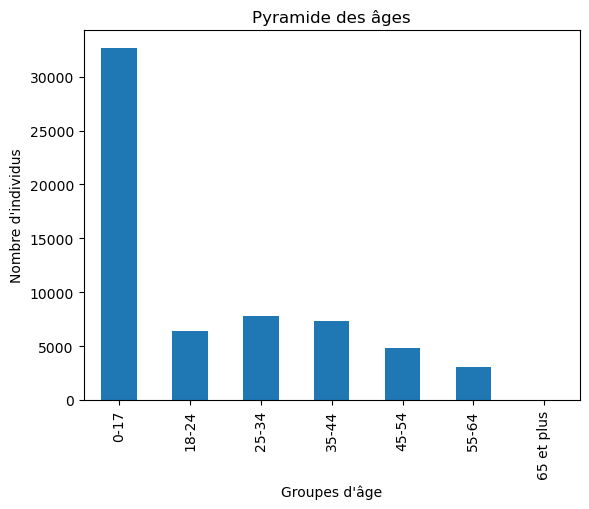

In [134]:
# fais une pyramide des âges des individus du dataframe
age_counts = df_anstat['age_grp'].value_counts().sort_index()
age_counts = age_counts.reindex(['0-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65 et plus'], fill_value=0)
age_counts.plot(kind='bar')
plt.title('Pyramide des âges')
plt.xlabel('Groupes d\'âge')
plt.ylabel('Nombre d\'individus')
plt.show()

In [144]:
# supprimer tous les individus qui ont un âge inferieur à 18 ans
df_anstat = df_anstat[df_anstat['age_num'] >= 18]
df_anstat

,idmen,idind,country,year,PanelHH,numind,vague,agro_zone,zaemil,region_name,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
0,2,4,CIV,2021,Menage panel,4,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,0,1
4,2,2,CIV,2021,Menage panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,0,1,1,0
5,2,1,CIV,2021,Menage panel,1,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,1,0
8,3,8,CIV,2021,Menage panel,1,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Non,Non,Non,Non,0.000000e+00,1,0,1,0
9,3,9,CIV,2021,Menage panel,2,1,ABIDJAN,ABIDJAN,AUTONOME D'ABIDJAN,...,Non,Non,Non,Non,Non,0.000000e+00,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64476,13861,64475,CIV,2021,Menage panel,1,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,7.981800e-01,1,0,1,0
64478,13862,64479,CIV,2021,Menage panel,1,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,3.217664e+07,1,0,1,0
64483,13862,64480,CIV,2021,Menage panel,2,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Non,Non,3.217664e+07,0,0,1,0
64485,13863,64487,CIV,2021,Menage panel,2,2,CENTRE,CENTRE (rural),MORONOU,...,Non,Non,Non,Oui,Non,8.566398e+06,0,1,1,0


## Variables à laisser

In [145]:
df_stat = df_anstat.drop(['idmen', 'idind', 'country', 'year', 'PanelHH', 'numind', 'vague', 'moustiq', 'zaemil', 'has_account_bank', 'est_scolarise'], axis=1)
df_stat

,agro_zone,region_name,department,city,milieu_resid,hhweight,resid,sex,age_num,lien,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
0,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,Féminin,29,"Fils, Fille",...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,0,1
4,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,Féminin,34,Conjoint ( e ),...,Oui,Non,Non,Oui,Non,0.000000e+00,0,1,1,0
5,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,Masculin,50,Chef de ménage,...,Oui,Non,Non,Oui,Non,0.000000e+00,1,0,1,0
8,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,Masculin,56,Chef de ménage,...,Non,Non,Non,Non,Non,0.000000e+00,1,0,1,0
9,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,Féminin,38,Conjoint ( e ),...,Non,Non,Non,Non,Non,0.000000e+00,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64476,CENTRE,MORONOU,M'BATTO,TIEMELEKRO,Rural,242.7796,Oui,Masculin,55,Chef de ménage,...,Non,Non,Non,Non,Non,7.981800e-01,1,0,1,0
64478,CENTRE,MORONOU,M'BATTO,TIEMELEKRO,Rural,242.7796,Oui,Masculin,36,Chef de ménage,...,Non,Non,Non,Non,Non,3.217664e+07,1,0,1,0
64483,CENTRE,MORONOU,M'BATTO,TIEMELEKRO,Rural,242.7796,Oui,Féminin,33,Conjoint ( e ),...,Non,Non,Non,Non,Non,3.217664e+07,0,0,1,0
64485,CENTRE,MORONOU,M'BATTO,TIEMELEKRO,Rural,242.7796,Oui,Féminin,37,Conjoint ( e ),...,Non,Non,Non,Oui,Non,8.566398e+06,0,1,1,0


In [58]:
df_fin = df_anstat.drop(['year', 'PanelHH', 'numind', 'vague', 'moustiq', 'zaemil', 'has_account_bank', 'est_scolarise'], axis=1)
df_fin

,idmen,idind,country,agro_zone,region_name,department,city,milieu_resid,hhweight,resid,...,frigo,cuisin,ordin,decod,car,superf,bancarise,volhor_manquant,salaire_mois_manquant,Stg_formel
0,2,4,CIV,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,...,Oui,Non,Non,Oui,Non,0.0,1,0,0,1
1,2,5,CIV,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
2,2,3,CIV,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
3,2,6,CIV,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
4,2,2,CIV,ABIDJAN,AUTONOME D'ABIDJAN,ABIDJAN,ABIDJAN,Urbain,1098.1172,Oui,...,Oui,Non,Non,Oui,Non,0.0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64486,13863,64490,CIV,CENTRE,MORONOU,M'BATTO,TIEMELEKRO,Rural,242.7796,Oui,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64487,13863,64489,CIV,CENTRE,MORONOU,M'BATTO,TIEMELEKRO,Rural,242.7796,Oui,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64488,13863,64491,CIV,CENTRE,MORONOU,M'BATTO,TIEMELEKRO,Rural,242.7796,Oui,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0
64489,13863,64488,CIV,CENTRE,MORONOU,M'BATTO,TIEMELEKRO,Rural,242.7796,Oui,...,Non,Non,Non,Oui,Non,8566398.0,0,1,1,0


# **Exportation Clean_Datas**

In [146]:
# Pour les statistiques

df_stat.to_csv("../DATAS/ANSTAT2021_dataset_Clean.csv", index=False, encoding="utf-8")

In [60]:
# Pour les statistiques

df_fin.to_csv("../DATAS/ANSTAT2021_dataset_AllVars_CLEAN.csv", index=False, encoding="utf-8")

In [61]:
df_fin.shape

(64474, 73)

In [62]:
df_fin.columns

Index(['idmen', 'idind', 'country', 'agro_zone', 'region_name', 'department',
       'city', 'milieu_resid', 'hhweight', 'resid', 'sex', 'age_num', 'lien',
       'marital_status', 'religion', 'ethnie', 'nation', 'agemar', 'mal30j',
       'aff30j', 'arrmal', 'durarr', 'con30j', 'hos12m', 'couvmal', 'handit',
       'handig', 'alfa', 'alfa2', 'scol', 'educ_scol', 'educ_hi', 'diplome',
       'telpor', 'internet', 'activ7j', 'activ12m', 'branch', 'sectins', 'csp',
       'volhor', 'salaire', 'emploi_sec', 'sectins_sec', 'csp_sec',
       'volhor_sec', 'salaire_sec', 'serviceconsult', 'persconsult',
       'salaire_mois', 'salaire_sec_mois', 'rev_total_mois', 'log_revenu',
       'sans_revenu', 'age_grp', 'a_assurance', 'alphabete', 'logem',
       'elec_ac', 'elec_ur', 'elec_ua', 'tv', 'fer', 'frigo', 'cuisin',
       'ordin', 'decod', 'car', 'superf', 'bancarise', 'volhor_manquant',
       'salaire_mois_manquant', 'Stg_formel'],
      dtype='object')

In [63]:
df_stat.shape

(64474, 70)

In [64]:
df_stat.columns

Index(['agro_zone', 'region_name', 'department', 'city', 'milieu_resid',
       'hhweight', 'resid', 'sex', 'age_num', 'lien', 'marital_status',
       'religion', 'ethnie', 'nation', 'agemar', 'mal30j', 'aff30j', 'arrmal',
       'durarr', 'con30j', 'hos12m', 'couvmal', 'handit', 'handig', 'alfa',
       'alfa2', 'scol', 'educ_scol', 'educ_hi', 'diplome', 'telpor',
       'internet', 'activ7j', 'activ12m', 'branch', 'sectins', 'csp', 'volhor',
       'salaire', 'emploi_sec', 'sectins_sec', 'csp_sec', 'volhor_sec',
       'salaire_sec', 'serviceconsult', 'persconsult', 'salaire_mois',
       'salaire_sec_mois', 'rev_total_mois', 'log_revenu', 'sans_revenu',
       'age_grp', 'a_assurance', 'alphabete', 'logem', 'elec_ac', 'elec_ur',
       'elec_ua', 'tv', 'fer', 'frigo', 'cuisin', 'ordin', 'decod', 'car',
       'superf', 'bancarise', 'volhor_manquant', 'salaire_mois_manquant',
       'Stg_formel'],
      dtype='object')

# **RESUME**